# Accelerated Data Science with RAPIDS #

## 06 - XGBoost ##

**Table of Contents**
<br>
This notebook uses use GPU-accelerated gradient boosting to predict the probability that a given individual is infected with the simulated virus. This notebook covers the below sections:
1. [Environment](#Environment)
2. [Load Data](#Load-Data)
3. [Train-Test Split](#Train-Test-Split)
4. [XGBoost](#XGBoost)
    * [Setting XGBoost Parameters](#Setting-XGBoost-Parameters)
    * [Training the Model](#Training-the-Model)
5. [Inspecting the Model](#Inspecting-the-Model)
6. [Making Predictions](#Making-Predictions)
7. [(Optional) Comparison: CPU-Only XGBoost](#(Optional)-Comparison:-CPU-Only-XGBoost)

## Environment ##
We will be using the [XGBoost](https://xgboost.readthedocs.io/en/latest/) library to create the gradient boosted model for this exercise.

In addition to the usual RAPIDS components, we import several libraries that will help us understand and evaluate the XGBoost model once we have trained it.

In [1]:
import cudf
import cupy as cp

from cuml.model_selection import train_test_split

# visualization
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
# import graphviz

# model analysis
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import xgboost as xgb

# xgboost version 1.0 or later is required to directly convert from cudf Dataframes to xgboost DMatrix format
print('XGBoost version: ', xgb.__version__)

XGBoost version:  3.3.0


## Load Data ##
For this notebook we load a subset of the population data, including both the columns we used before for logistic regression and the coordinate columns. XGBoost allows us to use data that have nonlinear relationships with the outcome of interest, and geospatial data often fall into that category.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# This cell must run to import the data for the example
import os

dir_path = '/content/drive/MyDrive/Accel_DS_RAPIDS'
file_path = 'part3/data/clean_uk_pop_full.csv'

print(f"Checking existence of directory: {dir_path}")
if os.path.exists(dir_path) and os.path.isdir(dir_path):
    print(f"The directory '{dir_path}' exists.")
else:
    print(f"Creating '{dir_path}'.")
    # Create data folder if it doesn't exist
    os.makedirs(dir_path, exist_ok=True)
absolute_path_to_file = os.path.join(dir_path, file_path)
print(f"\nChecking existence of file: {absolute_path_to_file}")
if os.path.exists(absolute_path_to_file):
    print(f"The file '{file_path}' exists.")
else:
    print(f"The file '{file_path}' not found.")
    print(f"Downloading ")
    # Download the file from Google Drive\
    import gdown
    url = "https://drive.google.com/uc?id=1VW59ZGVwgOfvHbttIwFagpZQkWBICTKh"
    gdown.download(url,absolute_path_to_file)

Mounted at /content/drive
Checking existence of directory: /content/drive/MyDrive/Accel_DS_RAPIDS
The directory '/content/drive/MyDrive/Accel_DS_RAPIDS' exists.

Checking existence of file: /content/drive/MyDrive/Accel_DS_RAPIDS/part3/data/clean_uk_pop_full.csv
The file 'part3/data/clean_uk_pop_full.csv' exists.


In [3]:
gdf = cudf.read_csv(absolute_path_to_file, usecols=['age', 'sex', 'northing', 'easting', 'infected'])

In [4]:
gdf.dtypes

,0
age,float64
sex,float64
northing,float64
easting,float64
infected,float64


In [5]:
gdf.shape

(58479894, 5)

In [6]:
gdf.head()

,age,sex,northing,easting,infected
0,0.0,0.0,515491.5313,430772.1875,0.0
1,0.0,0.0,503572.4688,434685.8750,0.0
2,0.0,0.0,517903.6563,432565.5313,0.0
3,0.0,0.0,517059.9063,427660.6250,0.0
4,0.0,0.0,509228.6875,425527.7813,0.0


Before splitting the data for training and testing, we check our memory status. We want to be below half the memory usage on the active GPU so that the temporary increase from the split still fits in memory.

In [8]:
!nvidia-smi

Thu Jul 23 07:03:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             30W /   70W |    2351MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Train-Test Split ##
We again use the splitting method to create training and testing data subsets, keeping in mind that we will be using additional memory by doing so.

In [9]:
x_train, x_test, y_train, y_test = train_test_split(gdf[['age', 'sex', 'northing', 'easting']], gdf['infected'])

In [10]:
!nvidia-smi

Thu Jul 23 07:04:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   68C    P0             31W /   70W |    5937MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**Note**: Now that we have training and testing subsets, we can delete the original data so we have room for the algorithm's memory overhead--not critical in this case, but a useful practice when trying to train on as much data as possible.

In [11]:
del(gdf)

## XGBoost ##

### Setting XGBoost Parameters ###
We can now set the parameters for this XGBoost training run. These will determine the type and size of trees being created, as well as the way we measure success.

The `cuda` device is a critical parameter: it tells XGBoost that we want the training to run on GPU.

For our use case, we again want to predict the probability that an individual is infected with the virus, so we set the `binary:logistic` objective (binary outcome, using the logistic method to get probabilities).

Other parameter options and meanings can be found at [XGBoost parameters](https://xgboost.readthedocs.io/en/latest/parameter.html).

In [12]:
params = {
    'max_depth':    8,
    'max_leaves':   2**8,
    'device': 'cuda',
    'tree_method':  'hist',
    'objective':    'binary:logistic',
    'grow_policy':  'lossguide',
    'eval_metric':  'logloss',
    'subsample':    '0.8'
}

### Training the Model ###
XGBoost uses a special, highly efficient data structure called a `DMatrix`, so we pass the training dataframes into it to create one.

Note that the data is remaining on GPU, passing directly from cuDF to XGBoost.

In [13]:
dtrain = xgb.DMatrix(x_train, y_train)

Now we are ready to train the model.

In [14]:
%time model = xgb.train(params, dtrain, num_boost_round=100)

CPU times: user 18.9 s, sys: 215 ms, total: 19.1 s
Wall time: 19.4 s


In [15]:
model.save_model("/content/drive/MyDrive/Accel_DS_RAPIDS/part3/xgboost_model.json")

In [16]:
print(x_train)
print(y_train)

           age  sex     northing      easting
53211278  66.0  1.0  153333.9844  628633.3125
44826      0.0  0.0  446542.1250  379148.8750
50629516  58.0  1.0  177916.5156  362400.6250
57731118  86.0  1.0  379936.2500  433719.6875
15493463  41.0  0.0  156372.7500  621398.8125
...        ...  ...          ...          ...
43017548  39.0  1.0  295075.4063  402933.0625
6388504   18.0  0.0  507024.5000  408058.9688
30253740   4.0  1.0  599451.8750  401133.4375
11073057  30.0  0.0  382038.6875  434000.0000
30025430   3.0  1.0  307403.4688  383212.5000

[43859920 rows x 4 columns]
53211278    0.0
44826       0.0
50629516    0.0
57731118    0.0
15493463    0.0
           ... 
43017548    0.0
6388504     0.0
30253740    0.0
11073057    0.0
30025430    0.0
Name: infected, Length: 43859920, dtype: float64


**Note**: As a point of comparison, code to run the CPU-only version of XGBoost is provided at the bottom of this exercise.

## Inspecting the Model ##
We can examine the model in several ways. First, we can see which features the model believes to be most important in its assessment. Higher F scores indicate higher estimated importance.

There appears to be a strong geospatial component to the infection distribution, since the easting and northing features have the highest F scores. In addition, age appears to have a stronger impact than sex in determining infection rates (consistent with the results we received from the logistic regression analysis).

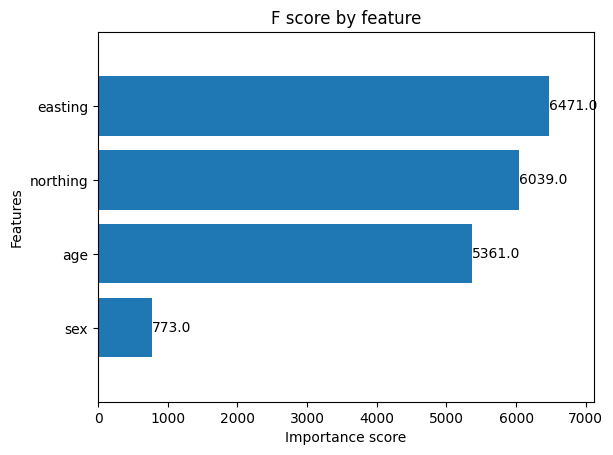

In [17]:
ax = xgb.plot_importance(model, height=.8)
ax.grid(False)
ax.set_title('F score by feature')
plt.show()

We can also pull out individual trees within the model and see exactly which decisions it uses for its contributions to the ensemble. Notice that as with all ensemble methods, individual trees may not appear to produce major differences in outcomes (values on the leaf nodes); the aggregation of often individually-weak trees into a strong model gives XGBoost its power.

Try changing `tree_idx` to examine different trees in the model. Changing `rankdir` to `'TB'` will reorient the trees to top-down.

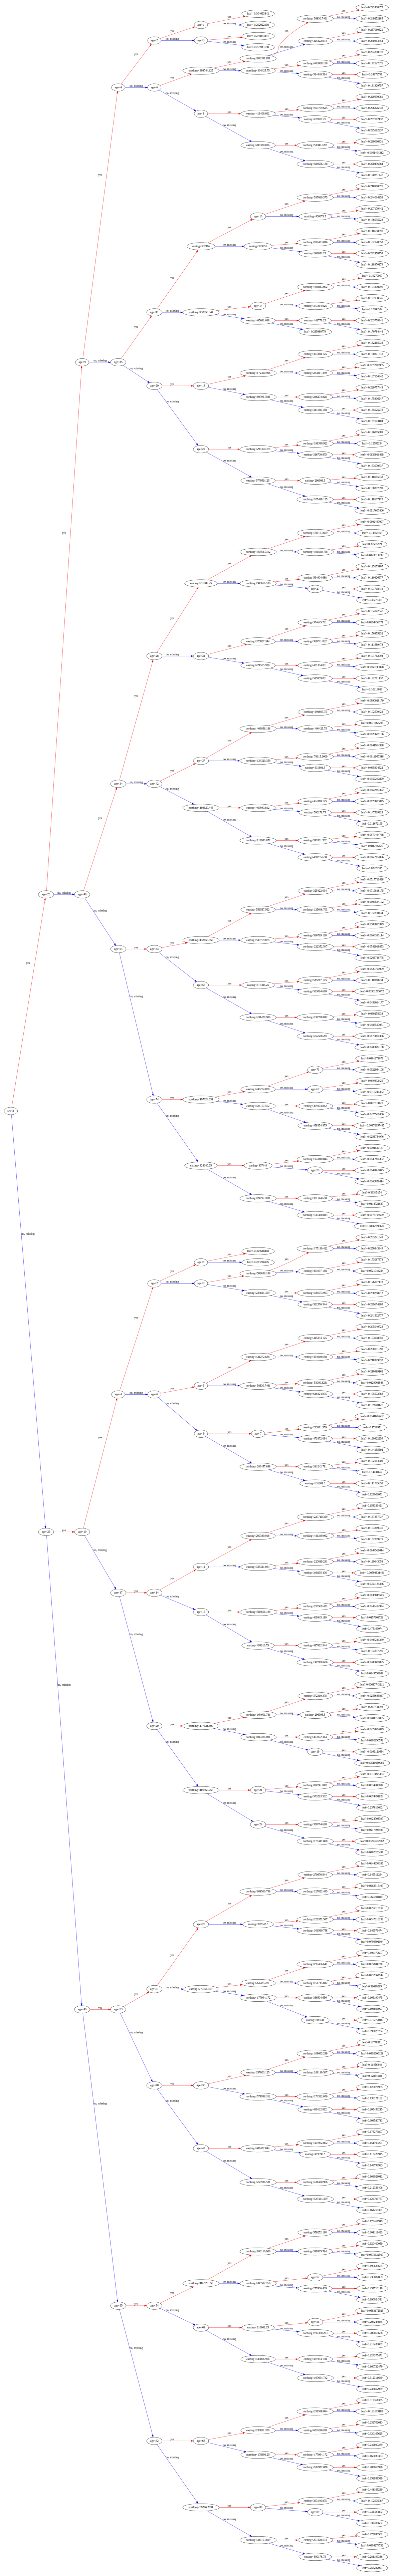

In [19]:
xgb.plot_tree(model, tree_idx=0, rankdir='LR')

# get current figure to set the size
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(100, 100)

## Making Predictions ##
Once we are comfortable with the model, we move to making predictions with it. We confirm that we will be making predictions on over 11 million rows of data.

In [20]:
x_test.shape

(14619974, 4)

We convert the *X* matrix to a `DMatrix` as before, then make a prediction for each row. Notice the amount of time it takes to make over 11 million predictions.

In [21]:
dtest = xgb.DMatrix(x_test)
%time y_pred = model.predict(dtest)

CPU times: user 501 ms, sys: 39.5 ms, total: 541 ms
Wall time: 560 ms


Now we would like to see how good those predictions were. One common evaluation method is to calculate the area under the curve (AUC) of the receiver operating characteristic (ROC) curve.

The predictions are a `numpy` array, so we convert the test labels to match, then run the ROC curve calculation.

In [22]:
y_test_cpu = cp.asnumpy(cp.array(y_test))
false_pos_rate, true_pos_rate, thresholds = roc_curve(y_test_cpu, y_pred)

Last, we can plot the curve and calculate the AUC score to help us assess the trade offs between true and false positive rates.

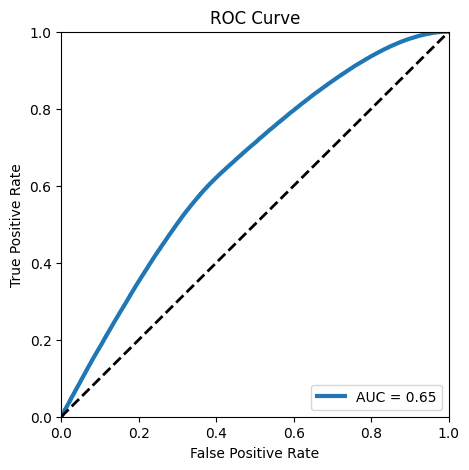

In [23]:
auc_result = auc(false_pos_rate, true_pos_rate)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(false_pos_rate, true_pos_rate, lw=3,
        label='AUC = {:.2f}'.format(auc_result))
ax.plot([0, 1], [0, 1], 'k--', lw=2)
ax.set(
    xlim=(0, 1),
    ylim=(0, 1),
    title="ROC Curve",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)
ax.legend(loc='lower right');
plt.show()

## (Optional) Comparison: CPU-Only XGBoost ##
Below we provide code for training and inferring from a CPU-only XGBoost using the same model parameters other than switching the histogram tree method from GPU to CPU.

In [ ]:
params['device'] = 'cpu'
dtrain_cpu = xgb.DMatrix(x_train.to_pandas(), y_train.to_pandas())
%time model_cpu = xgb.train(params, dtrain_cpu, num_boost_round=100)

In [ ]:
dtest_cpu = xgb.DMatrix(x_test.to_pandas())
%time y_pred_cpu = model_cpu.predict(dtest_cpu)